# $K\pi$ scattering data analysis

This notebook presents a reproduction of the $K\pi$ $T_{1u}$ spectrum GEVP analysis of [1]. To keep the code simple, `latan.datasets.arXiv_2406_19193` only implements the $T_{1u}$ $K\pi$ projection.

[1] [*Physical-mass calculation of $\rho(770)$ and $K^*(892)$ resonance parameters via $\pi\pi$ and $K\pi$ scattering amplitudes from lattice QCD*, P Boyle *et al.*, Phys. Rev. D 111(5), 2025](https://doi.org/10.1103/PhysRevD.111.054510).

In [1]:
import os

import h5py
import matplotlib.pyplot as plt
import numpy as np

import latan
from latan.datasets.arXiv_2406_19193 import data as kpi_paper

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## Data loading

Data is downloaded from the CERN Document Server, then post-processed into a $N_{\mathrm{conf}}\times N_{\mathrm{op}}\times N_{\mathrm{op}}\times N_{t}$ array for the $T_{1u}$ irrep, where $N_{\mathrm{conf}}$ is the number of configurations, $N_{\mathrm{op}}$ is the number of operators, and $N_{t}$ is the number of time slices. Time translations on the same configuration, as well as the three Cartesian irrep rows, are averaged. The final processed array is saved in `data_2406.19193_kpi_t1u.h5` (only a few MB).

The notebook does not overwrite existing files: an existing download directory skips the archive transfer, and an existing final HDF5 file is read.

*Warning: The download is about 64 GiB and expands to about 253 GiB; allow roughly 317 GiB of free space.*

1. Download

In [2]:
download_dir = "data_2406.19193_kpi_t1u"
correlator_path = f"./{download_dir}.h5"
if not os.path.exists(correlator_path):
    kpi_paper.download(
        download_dir,
        kpi_paper.IRREP_ARCHIVES["K-Pi"]["T1u[000]"],
        workers=3,
        progress=True,
    )
    trajectories = kpi_paper.trajectories(download_dir)
    print(
        f"using {len(trajectories)} trajectories: {trajectories[0]} ... {trajectories[-1]}"
    )
else:
    print(f"processed correlator {correlator_path} found, download skipped")

processed correlator ./data_2406.19193_kpi_t1u.h5 found, download skipped


2. Process

In [3]:
if not os.path.exists(correlator_path):
    kpi_paper.process_kpi_t1u(download_dir, trajectories, workers=8, progress=True)
else:
    print(f"processed correlator {correlator_path} found")
with h5py.File(correlator_path, "r") as file:
    correlator_data = np.asarray(file["kpi_t1u"])
print(f"{correlator_data.shape} array read")

processed correlator ./data_2406.19193_kpi_t1u.h5 found
(90, 5, 5, 96) array read


## GEVP

The basis contains the vector bilinear and the four $K\pi$ shells in Table I.  The three Cartesian rows of the $T_{1u}$ irrep are averaged, as described in Sec. II D; the Wick-contraction factors are those of Appendix C.

In [4]:
n_bootstrap = 2000
boot = latan.NonparametricBootstrap(240619193)
# The released contraction convention gives a negative-definite C(t0).
# Multiplying the complete matrix by -1 leaves the GEVP unchanged.
correlator = boot.sample(-np.real(correlator_data), n_bootstrap)
nt = int(correlator.shape[-1])

In [5]:
t0 = 3
gev = latan.gevp(correlator, t0=t0)
n_op = int(gev.shape[-2])
if not np.all(np.diff(gev, axis=-2) <= 0):
    raise RuntimeError("GEVP eigenvalues are not ordered consistently")

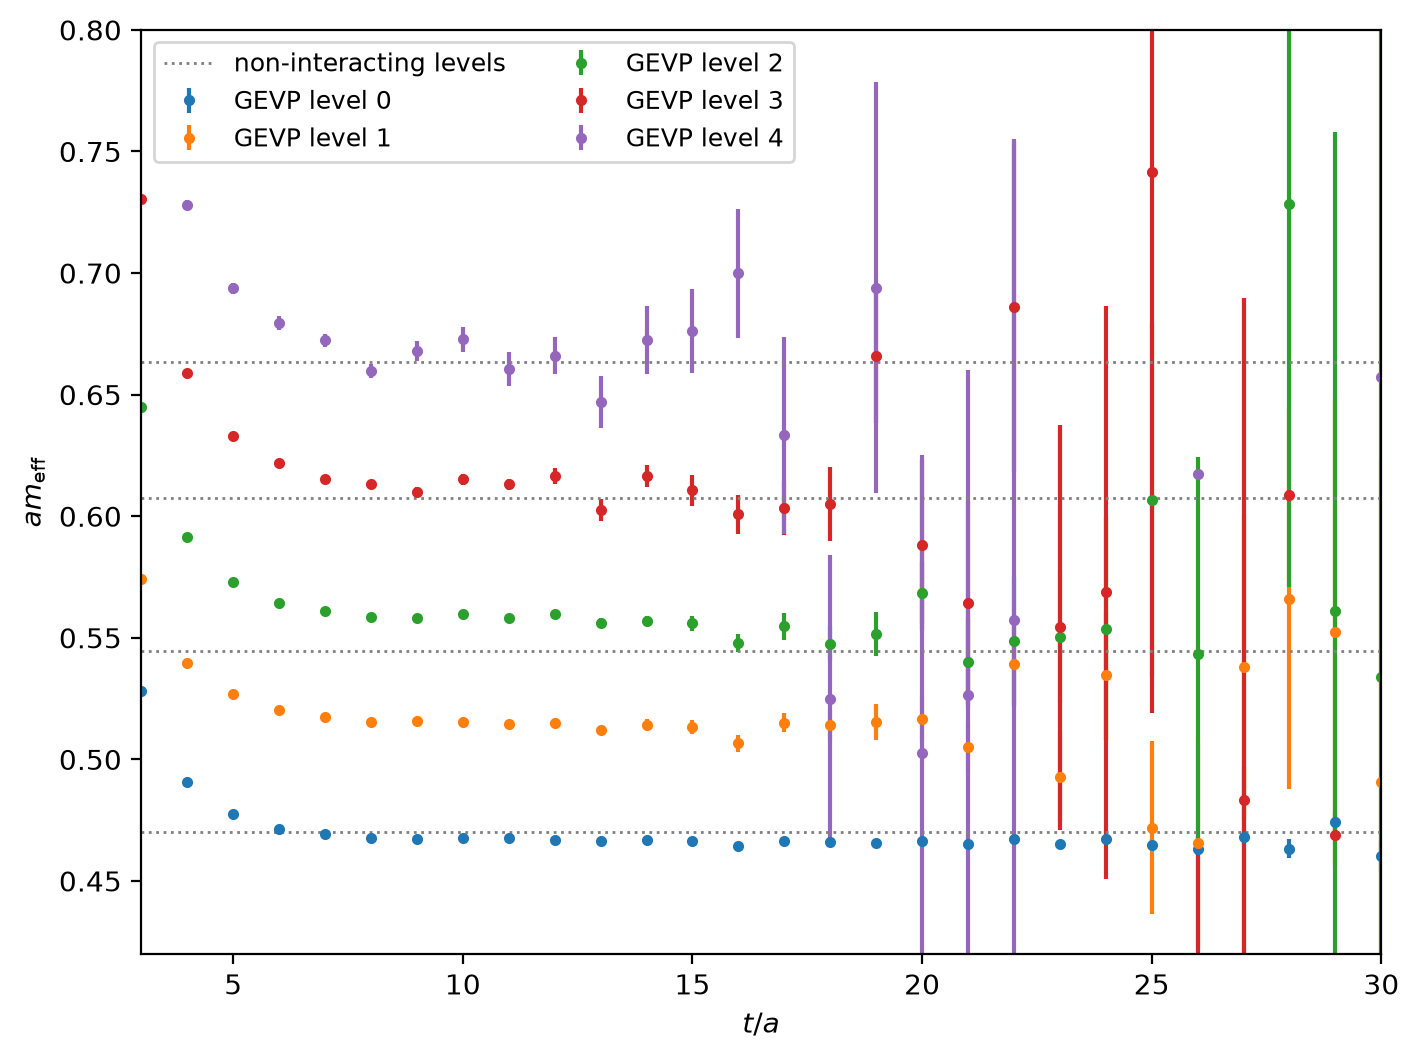

In [6]:
# Eq. (26), with L/a = 48 and the masses quoted in Sec. III A.
a_inverse_mev = 1729.5
a_mpi, a_mk = np.array((138.5, 498.9)) / a_inverse_mev
momentum_unit = 2 * np.pi / 48
noninteracting = np.array([
    np.sqrt(a_mk**2 + d2 * momentum_unit**2) + np.sqrt(a_mpi**2 + d2 * momentum_unit**2)
    for d2 in range(1, 5)
])
with np.errstate(divide="ignore", invalid="ignore"):
    effective_mass = latan.eff_mass_log(gev)
plt.figure(figsize=(8, 6))
for level in range(n_op):
    plt.errorbar(
        np.arange(nt - 1),
        effective_mass.central[level],
        effective_mass.error()[level],
        fmt=".",
        label=f"GEVP level {level}",
    )
for index, energy in enumerate(noninteracting):
    plt.axhline(
        energy,
        color="0.5",
        ls=":",
        lw=1,
        label="non-interacting levels" if index == 0 else None,
    )
plt.xlim(3, 30)
plt.ylim(0.42, 0.8)
plt.xlabel(r"$t/a$")
plt.ylabel(r"$a m_{\mathrm{eff}}$")
plt.legend(ncol=2, fontsize=9)
plt.show()

## Correlated single-exponential fits
Fit $\lambda_n(t)=Z_n\exp(-E_n t)$ to the GEVP eigenvalues with bootstrap covariance.

In [7]:
def exp1(t, p):
    return p[..., 1] * np.exp(-p[..., 0] * t[..., 0])


fit_range = (8, 16)
fit_times = np.arange(fit_range[0], fit_range[1] + 1)
model = latan.Model(exp1, n_var=1, n_par=2, parameter_names=("E", "Z"))
fits = []
for level in range(n_op):
    samples = latan.BootstrapArray(gev[:, level, fit_times])
    correlated = latan.make_correlated_data(samples)
    xy_data = latan.XYData(correlated, x=[fit_times], y_indices=[0])
    e_guess = effective_mass.central[level, fit_times[0]]
    p0 = np.array((e_guess, samples.central[0] * np.exp(e_guess * fit_times[0])))
    fits.append(latan.fit(xy_data, model, p0, bootstrap=samples, workers=4))
for level, result in enumerate(fits):
    print(f"level {level + 1}")
    display(result)

level 1


E = 0.4672 ± 0.0002756
Z = 3.674 ± 0.008579
chi^2/dof = 13.94/7 = 2
  p-value = 0.052
CDR at minimum 29 dB

level 2


E = 0.5151 ± 0.0004424
Z = 4.232 ± 0.01469
chi^2/dof = 5.846/7 = 0.84
  p-value = 0.56
CDR at minimum 22 dB

level 3


E = 0.5589 ± 0.0004171
Z = 4.648 ± 0.01689
chi^2/dof = 5.627/7 = 0.8
  p-value = 0.58
CDR at minimum 23 dB

level 4


E = 0.6128 ± 0.0006751
Z = 5.167 ± 0.02994
chi^2/dof = 10.2/7 = 1.5
  p-value = 0.18
CDR at minimum 18 dB

level 5


E = 0.6649 ± 0.001108
Z = 5.632 ± 0.06049
chi^2/dof = 7.059/7 = 1
  p-value = 0.42
CDR at minimum 13 dB